In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display the first 5 rows to ensure it loaded correctly
df.head()

Matplotlib is building the font cache; this may take a moment.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check the size of the dataset (rows, columns)
print(f"Dataset Shape: {df.shape}\n")

# Get a summary of columns, non-null counts, and data types
df.info()

Dataset Shape: (7043, 21)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non

In [3]:
# Convert 'TotalCharges' to numeric, turning blank spaces into NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many missing values (NaN) exist in each column now
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [4]:
# Drop the 11 rows with missing values
df.dropna(inplace=True)

# Drop 'customerID' as it holds no predictive value
df.drop('customerID', axis=1, inplace=True)

# Verify the changes
print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (7032, 20)


C:\Users\pradh\AppData\Local\Temp\ipykernel_25908\1708023588.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


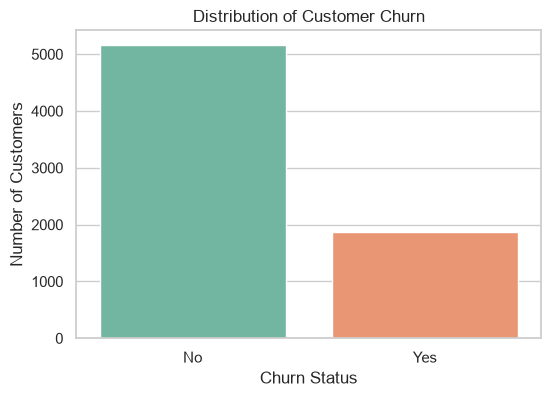

In [5]:
# Set the visual style for all plots
sns.set_theme(style="whitegrid")

# Create a bar chart showing the total number of Churn vs No Churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

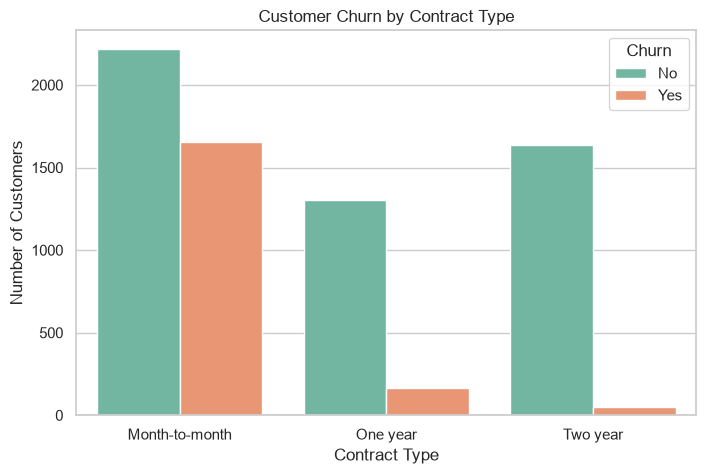

In [6]:
# Create a chart comparing Contract type and Churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

C:\Users\pradh\AppData\Local\Temp\ipykernel_25908\3610050449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


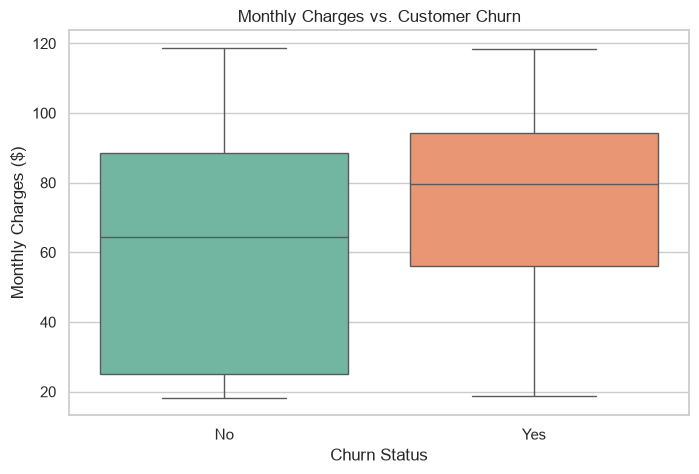

In [7]:
# Create a boxplot to see the distribution of monthly charges against churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges vs. Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.show()

In [8]:
# Convert the target variable 'Churn' to 1 (Yes) and 0 (No)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Use pandas get_dummies to convert all other text columns into numbers
# drop_first=True prevents redundant columns (e.g., instead of 'Gender_Male' and 'Gender_Female', it just keeps one)
df = pd.get_dummies(df, drop_first=True)

# Look at the new structure
print(f"New Dataset Shape: {df.shape}")
df.head()

New Dataset Shape: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [9]:
from sklearn.model_selection import train_test_split

# X contains all the features (our inputs). y contains only the target (our output)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features size: {X_train.shape}")
print(f"Testing features size: {X_test.shape}")

Training features size: (5625, 30)
Testing features size: (1407, 30)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Scale the numerical features so the model can converge quickly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize the model
log_model = LogisticRegression(max_iter=1000)

# 3. Train the model using the SCALED training data
log_model.fit(X_train_scaled, y_train)

# 4. Make predictions on the SCALED test data
log_predictions = log_model.predict(X_test_scaled)

print("Model successfully trained using Feature Scaling!")

Model successfully trained using Feature Scaling!


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1. Calculate standard Accuracy
log_accuracy = accuracy_score(y_test, log_predictions)
print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")

# 2. Get probabilities for ROC-AUC
# [:, 1] gets the probability specifically for class '1' (Churn)
log_probabilities = log_model.predict_proba(X_test_scaled)[:, 1]

# 3. Calculate ROC-AUC score
log_roc_auc = roc_auc_score(y_test, log_probabilities)
print(f"Logistic Regression ROC-AUC: {log_roc_auc:.4f}\n")

# 4. Print a detailed report
print("Detailed Classification Report:")
print(classification_report(y_test, log_predictions))

Logistic Regression Accuracy: 0.7875
Logistic Regression ROC-AUC: 0.8319

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [21]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the Decision Tree
# We set max_depth=5 to stop the tree from growing too large and memorizing the data (overfitting)
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# 2. Train the model
tree_model.fit(X_train_scaled, y_train)

# 3. Make predictions and get probabilities
tree_predictions = tree_model.predict(X_test_scaled)
tree_probabilities = tree_model.predict_proba(X_test_scaled)[:, 1]

print("Decision Tree Model successfully trained!")

Decision Tree Model successfully trained!


In [22]:
# Evaluate the Decision Tree
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_roc_auc = roc_auc_score(y_test, tree_probabilities)

print("--- Final Model Comparison ---")
print(f"Logistic Regression | Accuracy: {log_accuracy:.4f} | ROC-AUC: {log_roc_auc:.4f}")
print(f"Decision Tree       | Accuracy: {tree_accuracy:.4f} | ROC-AUC: {tree_roc_auc:.4f}")

--- Final Model Comparison ---
Logistic Regression | Accuracy: 0.7875 | ROC-AUC: 0.8319
Decision Tree       | Accuracy: 0.7754 | ROC-AUC: 0.8130
